# Simulink vs Neural Network — Open-Loop Validation

**Model used:** lag-2 tuned [100,40], BATCH_SEED=42, 20 batches (primary result)

**Approach:** Full-roast autoregressive rollout on a held-out validation roast.
The NN receives only the true initial state at t=0 and the full control trajectory,
then feeds its own predictions back as lagged states for every subsequent step.
Predictions are compared against the Simulink-generated ground truth T_b and X_db.

**What this shows:** Whether the surrogate model can track a complete roast profile
from existing data — not just 30-second MPC windows, but the full roast duration.
Error accumulation over hundreds of steps is expected and is itself an informative finding.


## 1. Imports

In [80]:
import os, json, pickle, random, warnings
from pathlib import Path

import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn

from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)


Device: cpu


## 2. Configuration

Set paths to the saved results from the 20-batch seed-42 run.

In [81]:
# ── Paths ──────────────────────────────────────────────────────────────────
RESULTS_DIR  = Path('/home/ma-stud/Downloads/Python example files/results_20batches')
BATCH_ROOT   = Path('/home/ma-stud/Downloads/Pierl_Test/simulink/input_batches')

# ── Model to use ───────────────────────────────────────────────────────────
LAG_DEPTH = 2   # lag-2 tuned [100,40], winner from seed-42 20-batch run

# ── Validation roast selection ─────────────────────────────────────────────
# Set RANDOM_ROAST = True  -> picks a different roast every run
# Set RANDOM_ROAST = False -> uses the fixed index in VAL_ROAST_IDX
RANDOM_ROAST  = True
VAL_ROAST_IDX = 0      # only used when RANDOM_ROAST = False
ROAST_SEED    = None   # set an integer (e.g. 7) to get reproducible random picks

# ── Constants (must match training notebook exactly) ───────────────────────
T_B_RANGE        = 300.0
X_DB_RANGE       = 1.0
SEED             = 42
BATCH_SEED       = 42
N_BATCHES_SAMPLE = 20
N_BATCHES_TOTAL  = 1000
TRAIN_RATIO      = 0.8
MASTER_N         = 20

print(f'Results dir  : {RESULTS_DIR}')
print(f'Lag depth    : {LAG_DEPTH}')
print(f'Random roast : {RANDOM_ROAST}')


Results dir  : /home/ma-stud/Downloads/Python example files/results_20batches
Lag depth    : 2
Random roast : True


## 3. Model Architecture

Must match exactly what was used during training.

In [82]:
def input_dim_for_lag(n_lags):
    return 5 + 2 * (n_lags + 1)


class LaggedMLP(nn.Module):
    def __init__(self, input_dim, hidden1=64, hidden2=64, output_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1), nn.ReLU(),
            nn.Linear(hidden1, hidden2),   nn.ReLU(),
            nn.Linear(hidden2, output_dim)
        )
    def forward(self, x): return self.net(x)


print(f'Input dim for lag-{LAG_DEPTH}: {input_dim_for_lag(LAG_DEPTH)}')


Input dim for lag-2: 11


## 4. Load Saved Model, Scalers, and Config

In [83]:
# ── Load config ────────────────────────────────────────────────────────────
config_path = RESULTS_DIR / f'model_config_lag{LAG_DEPTH}.json'
with open(config_path) as f:
    config = json.load(f)

print('Model config:')
for k, v in config.items():
    print(f'  {k}: {v}')

# ── Load scalers ───────────────────────────────────────────────────────────
with open(RESULTS_DIR / f'x_scaler_lag{LAG_DEPTH}.pkl', 'rb') as f:
    x_sc = pickle.load(f)
with open(RESULTS_DIR / f'y_scaler_lag{LAG_DEPTH}.pkl', 'rb') as f:
    y_sc = pickle.load(f)

print(f'\nX scaler: mean shape {x_sc.mean_.shape}')
print(f'Y scaler: mean shape {y_sc.mean_.shape}')

# ── Rebuild model and load weights ─────────────────────────────────────────
model = LaggedMLP(
    input_dim=config['input_dim'],
    hidden1=config['hidden1'],
    hidden2=config['hidden2'],
    output_dim=config['output_dim']
).to(DEVICE)

weights_path = RESULTS_DIR / f'final_model_lag{LAG_DEPTH}.pt'
model.load_state_dict(torch.load(weights_path, map_location=DEVICE))
model.eval()

print(f'\nModel loaded: [{config["hidden1"]},{config["hidden2"]}]')
print(f'Architecture: input({config["input_dim"]}) -> '
      f'{config["hidden1"]} -> {config["hidden2"]} -> 2')
total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')


Model config:
  n_lags: 2
  input_dim: 11
  hidden1: 100
  hidden2: 40
  output_dim: 2
  lr: 0.00042946755140337527
  weight_decay: 1.1799062523159305e-06
  T_B_RANGE: 300.0
  X_DB_RANGE: 1.0
  horizon_steps: 30
  n_batches: 20
  batch_seed: 42

X scaler: mean shape (11,)
Y scaler: mean shape (2,)

Model loaded: [100,40]
Architecture: input(11) -> 100 -> 40 -> 2
Total parameters: 5,322


## 5. Data Loading Utilities

Same HDF5 loading functions as the training notebook.

In [84]:
def resolve_matlab_field(f, group, field_name):
    obj = group[field_name]
    try:
        arr = np.array(obj)
    except Exception:
        arr = None
    if arr is not None and arr.dtype.kind in ('i','u','f'):
        return np.squeeze(arr)
    if arr is not None and arr.size == 1:
        ref = arr.reshape(-1)[0]
        try:
            return np.squeeze(np.array(f[ref]))
        except Exception:
            pass
    try:
        ref = obj[0, 0]
        return np.squeeze(np.array(f[ref]))
    except Exception:
        pass
    raise ValueError(f"Could not resolve field '{field_name}'")


def safe_constant_value(x, name='value'):
    x = np.array(x).squeeze()
    if x.shape == ():  return float(x)
    if x.size == 1:    return float(x.reshape(-1)[0])
    flat = x.reshape(-1)
    if np.allclose(flat, flat[0], rtol=1e-6, atol=1e-8): return float(flat[0])
    raise ValueError(f'Expected scalar-like {name}, got shape {x.shape}')


def load_one_roast(mat_path, idx):
    with h5py.File(mat_path, 'r') as f:
        io_ref = f['inputs_and_outputs'][0, idx]
        oo_ref = f['inputs_and_outputs'][1, idx]
        in_g, out_g = f[io_ref], f[oo_ref]
        Time  = resolve_matlab_field(f, in_g,  'Time').astype(np.float32)
        T_g   = resolve_matlab_field(f, in_g,  'T_gi').astype(np.float32)
        m_dot = resolve_matlab_field(f, in_g,  'm_dot').astype(np.float32)
        T_b   = resolve_matlab_field(f, out_g, 'T_b').astype(np.float32)
        X_db  = resolve_matlab_field(f, out_g, 'X_db').astype(np.float32)
        m_b0  = safe_constant_value(resolve_matlab_field(f, in_g, 'm_b0'),  name='m_b0')
        d_b0  = safe_constant_value(resolve_matlab_field(f, in_g, 'd_b0'),  name='d_b0')
        X_b0  = safe_constant_value(resolve_matlab_field(f, in_g, 'X_0db'), name='X_0db')
    n = min(len(Time), len(T_g), len(m_dot), len(T_b), len(X_db))
    return {
        'Time': Time[:n], 'T_g': T_g[:n], 'm_dot': m_dot[:n],
        'T_b':  T_b[:n],  'X_db': X_db[:n],
        'm_b0': np.float32(m_b0), 'd_b0': np.float32(d_b0), 'X_b0': np.float32(X_b0),
    }


def get_num_roasts(mat_path):
    with h5py.File(mat_path, 'r') as f:
        return f['inputs_and_outputs'].shape[1]

print('Data loading utilities defined.')


Data loading utilities defined.


## 6. Rebuild Validation Roast Index

Recreate the exact same train/val split used during training (same seed, same batch selection).
This guarantees the roast we pick is genuinely held-out — never seen during training.

In [85]:
def get_all_batch_paths(batch_root, n_total):
    paths = []
    for i in range(1, n_total + 1):
        p = batch_root / f'input_batch_{i}.mat'
        if p.exists():
            paths.append(p)
    return paths


def get_superset_batch_paths(batch_root, n_total, master_n, n_use, seed):
    all_paths = get_all_batch_paths(batch_root, n_total)
    master_n  = min(master_n, len(all_paths))
    rng       = np.random.default_rng(seed)
    master_idx = sorted(rng.choice(len(all_paths), size=master_n, replace=False))
    master_list = [all_paths[i] for i in master_idx]
    return master_list[:n_use]


def build_roast_index(batch_paths):
    roast_index, gid = [], 0
    for path in batch_paths:
        n = get_num_roasts(path)
        for local_idx in range(n):
            roast_index.append((gid, str(path), local_idx))
            gid += 1
    return roast_index


def roast_level_split(roast_index, train_ratio=0.8, seed=42):
    ids = list(range(len(roast_index)))
    rng = np.random.default_rng(seed)
    rng.shuffle(ids)
    n_train = int(len(ids) * train_ratio)
    train_roasts = [roast_index[i] for i in sorted(ids[:n_train])]
    val_roasts   = [roast_index[i] for i in sorted(ids[n_train:])]
    return train_roasts, val_roasts


# Rebuild exactly as in training
batch_paths  = get_superset_batch_paths(
    BATCH_ROOT, N_BATCHES_TOTAL,
    master_n=MASTER_N, n_use=N_BATCHES_SAMPLE, seed=BATCH_SEED)
roast_index  = build_roast_index(batch_paths)
train_roasts, val_roasts = roast_level_split(roast_index, TRAIN_RATIO, SEED)

# ── Select roast ───────────────────────────────────────────────────────────
if RANDOM_ROAST:
    _rng = np.random.default_rng(ROAST_SEED)   # None = truly random each run
    chosen_idx = int(_rng.integers(0, len(val_roasts)))
else:
    chosen_idx = VAL_ROAST_IDX

print(f'Total roasts : {len(roast_index):,}')
print(f'Train roasts : {len(train_roasts):,}')
print(f'Val roasts   : {len(val_roasts):,}')
print(f'Val roasts   : {len(val_roasts):,}')
print(f'\nSelected val roast index : {chosen_idx}')
print(f'  -> {val_roasts[chosen_idx][1]}')
print(f'  -> local idx {val_roasts[chosen_idx][2]}')


Total roasts : 18,985
Train roasts : 15,188
Val roasts   : 3,797
Val roasts   : 3,797

Selected val roast index : 1984
  -> /home/ma-stud/Downloads/Pierl_Test/simulink/input_batches/input_batch_644.mat
  -> local idx 435


## 7. Load and Inspect the Selected Validation Roast

In [86]:
# ── Find a roast with realistic temperature profile ───────────────────────
MIN_FINAL_TB_C = 130.0
MIN_DURATION   = 300

print(f'Searching for a roast with final T_b > {MIN_FINAL_TB_C}°C '
      f'and duration > {MIN_DURATION}s ...')

found_idx = None
for candidate_idx in range(len(val_roasts)):
    _, mp_c, li_c = val_roasts[candidate_idx]
    r_check    = load_one_roast(mp_c, li_c)
    final_tb_c = float(r_check['T_b'][-1]) - 273.15
    duration   = len(r_check['T_b'])
    if final_tb_c > MIN_FINAL_TB_C and duration > MIN_DURATION:
        found_idx = candidate_idx
        print(f'  Found at val index {candidate_idx}: '
              f'final T_b = {final_tb_c:.1f}°C, duration = {duration}s')
        break

if found_idx is None:
    print('WARNING: No roast met criteria. Falling back to chosen_idx.')
    found_idx = chosen_idx

chosen_idx = found_idx

# ── Explicitly reload the chosen roast ────────────────────────────────────
# r_check above was a temporary variable used only for screening.
# We reload here to guarantee roast, mat_path, local_idx are all consistent.
_, mat_path, local_idx = val_roasts[chosen_idx]
roast = load_one_roast(mat_path, local_idx)

T_b_true  = roast['T_b']
X_db_true = roast['X_db']
T_g       = roast['T_g']
m_dot     = roast['m_dot']
time_vec  = roast['Time']
L         = len(time_vec)

print(f'\nSelected roast:')
print(f'  File          : {Path(mat_path).name}, local idx {local_idx}')
print(f'  Duration      : {L} seconds')
print(f'  Initial T_b   : {T_b_true[0]:.2f} K  ({T_b_true[0]-273.15:.1f}°C)')
print(f'  Final T_b     : {T_b_true[-1]:.2f} K  ({T_b_true[-1]-273.15:.1f}°C)')
print(f'  Max T_b       : {T_b_true.max():.2f} K  ({T_b_true.max()-273.15:.1f}°C)')
print(f'  Initial X_db  : {X_db_true[0]:.4f}')
print(f'  Final X_db    : {X_db_true[-1]:.4f}')
print(f'  Delta X_db    : {(X_db_true[0]-X_db_true[-1]):.4f}')
print(f'  Bean mass     : {roast["m_b0"]:.3f} kg')
print(f'  Bean diameter : {roast["d_b0"]*1000:.2f} mm')
print(f'  T_gi range    : [{T_g.min():.1f}, {T_g.max():.1f}] K '
      f'({T_g.min()-273.15:.1f} to {T_g.max()-273.15:.1f}°C)')
print(f'  m_dot range   : [{m_dot.min():.3f}, {m_dot.max():.3f}] kg/s')


Searching for a roast with final T_b > 130.0°C and duration > 300s ...
  Found at val index 10: final T_b = 141.7°C, duration = 775s

Selected roast:
  File          : input_batch_85.mat, local idx 53
  Duration      : 775 seconds
  Initial T_b   : 293.15 K  (20.0°C)
  Final T_b     : 414.83 K  (141.7°C)
  Max T_b       : 414.83 K  (141.7°C)
  Initial X_db  : 0.6120
  Final X_db    : 0.2771
  Delta X_db    : 0.3349
  Bean mass     : 2.984 kg
  Bean diameter : 7.87 mm
  T_gi range    : [280.7, 558.3] K (7.5 to 285.1°C)
  m_dot range   : [0.026, 1.000] kg/s


## 8. Visualise the Control Inputs (APRBS Trajectories)

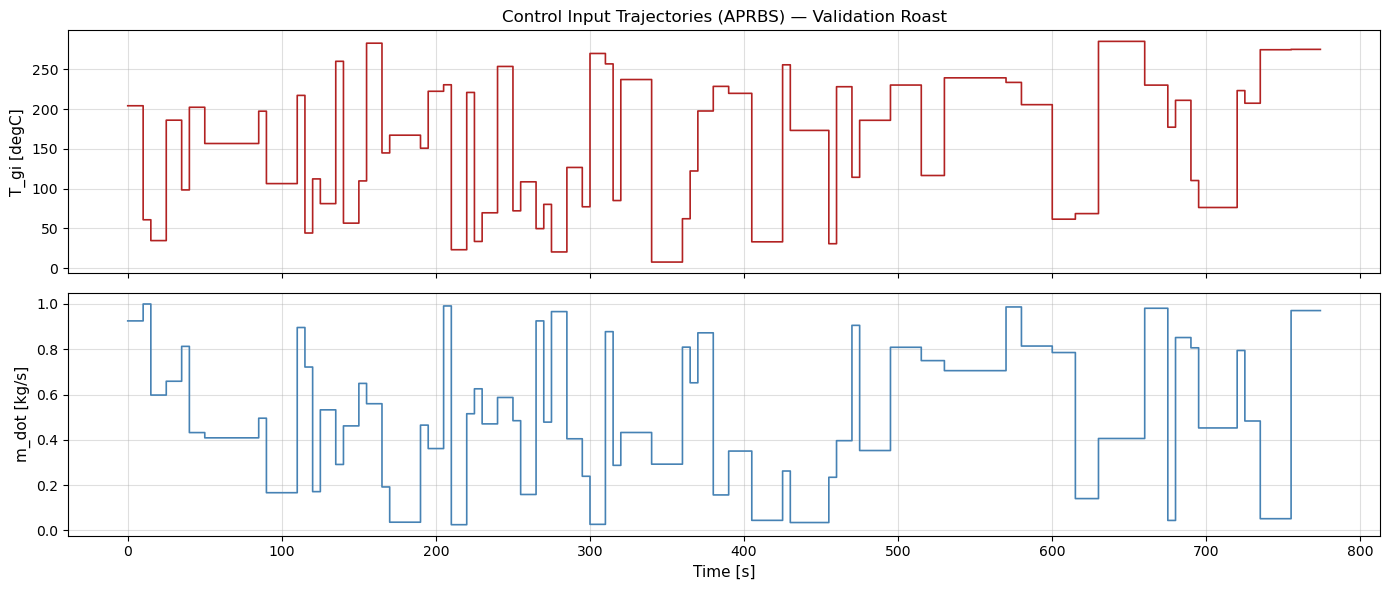

In [87]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].step(time_vec, T_g - 273.15, where='post', color='firebrick', linewidth=1.2)
axes[0].set_ylabel('T_gi [degC]', fontsize=11)
axes[0].set_title('Control Input Trajectories (APRBS) — Validation Roast', fontsize=12)
axes[0].grid(True, alpha=0.4)

axes[1].step(time_vec, m_dot, where='post', color='steelblue', linewidth=1.2)
axes[1].set_ylabel('m_dot [kg/s]', fontsize=11)
axes[1].set_xlabel('Time [s]', fontsize=11)
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()


## 9. Full-Roast Autoregressive Rollout

Starting from the true initial state at t=0, the NN predicts one step at a time,
feeding its own predictions back as lagged states for all subsequent steps.
Only the control inputs (T_gi, m_dot) and the batch parameters come from the true data.
The state (T_b, X_db) history is built entirely from the model's own predictions after t=0.

In [88]:
def full_roast_rollout(model, x_sc, y_sc, roast, n_lags, device='cpu'):
    """
    Full-roast autoregressive rollout from t=0 to t=L-1.

    For the first n_lags steps, true historical states are used to
    initialise the lag buffer (since there are no predictions yet).
    From step n_lags onward, the buffer is filled entirely with the
    model's own predictions.

    Returns arrays pred_Tb and pred_X of length L-1,
    corresponding to predictions for t=1 through t=L.
    """
    T_g       = roast['T_g']
    m_dot_arr = roast['m_dot']
    T_b_true  = roast['T_b']
    X_db_true = roast['X_db']
    m_b0, X_b0, d_b0 = roast['m_b0'], roast['X_b0'], roast['d_b0']
    L   = len(T_g)
    dim = input_dim_for_lag(n_lags)

    pred_Tb = np.zeros(L - 1, dtype=np.float32)
    pred_X  = np.zeros(L - 1, dtype=np.float32)

    # Lag buffer: index 0 = most recent, index n_lags = oldest
    # Initialise with true values for the first n_lags+1 time steps
    Tb_buf = [float(T_b_true[max(0, n_lags - k)]) for k in range(n_lags + 1)]
    X_buf  = [float(X_db_true[max(0, n_lags - k)]) for k in range(n_lags + 1)]

    model.eval()
    with torch.no_grad():
        for t in range(n_lags, L - 1):
            # Build feature vector
            feat = np.zeros(dim, dtype=np.float32)
            feat[0] = T_g[t]
            feat[1] = m_dot_arr[t]
            feat[2] = m_b0
            feat[3] = X_b0
            feat[4] = d_b0
            for lag in range(n_lags + 1):
                feat[5 + 2*lag] = Tb_buf[lag]
                feat[6 + 2*lag] = X_buf[lag]

            # Scale, predict, inverse-scale
            feat_s = x_sc.transform(feat.reshape(1, -1)).astype(np.float32)
            pred_s = model(torch.tensor(feat_s, device=device)).cpu().numpy()
            pred   = y_sc.inverse_transform(pred_s)[0]

            pTb = float(pred[0])
            pX  = float(pred[1])

            pred_Tb[t - n_lags] = pTb
            pred_X[t  - n_lags] = pX

            # Roll buffer: insert new prediction at front
            Tb_buf = [pTb] + Tb_buf[:-1]
            X_buf  = [pX]  + X_buf[:-1]

    # Return aligned arrays: pred corresponds to time steps n_lags+1 ... L
    return pred_Tb, pred_X


print('Running full-roast rollout...')
import time
t0 = time.time()
pred_Tb, pred_X = full_roast_rollout(model, x_sc, y_sc, roast,
                                      n_lags=LAG_DEPTH, device=DEVICE)
elapsed = time.time() - t0

# The predictions correspond to time steps n_lags+1 ... L
# Ground truth aligned to same window
t_start     = LAG_DEPTH
time_pred   = time_vec[t_start + 1:]       # time axis for predictions
true_Tb_win = T_b_true[t_start + 1:]       # ground truth aligned
true_X_win  = X_db_true[t_start + 1:]

# Trim pred arrays to match
pred_Tb_plot = pred_Tb[:len(time_pred)]
pred_X_plot  = pred_X[:len(time_pred)]

# Compute error metrics
abs_Tb  = np.abs(pred_Tb_plot - true_Tb_win)
abs_X   = np.abs(pred_X_plot  - true_X_win)
rel_Tb  = abs_Tb / T_B_RANGE  * 100
rel_X   = abs_X  / X_DB_RANGE * 100

print(f'Rollout complete in {elapsed:.1f}s')
print(f'Prediction length: {len(pred_Tb_plot)} steps')
print()
print('===== Full-Roast Rollout Metrics =====')
print(f'  T_b  MAE     : {np.mean(abs_Tb):.4f} K')
print(f'  T_b  rel err : {np.mean(rel_Tb):.3f}%')
print(f'  T_b  max err : {np.max(abs_Tb):.4f} K')
print(f'  X_db MAE     : {np.mean(abs_X):.6f}')
print(f'  X_db rel err : {np.mean(rel_X):.3f}%')
print(f'  X_db max err : {np.max(abs_X):.6f}')
print()
print('Note: full-roast errors are higher than 30s MPC window errors')
print('because prediction errors accumulate over hundreds of steps.')


Running full-roast rollout...
Rollout complete in 0.0s
Prediction length: 772 steps

===== Full-Roast Rollout Metrics =====
  T_b  MAE     : 1.3068 K
  T_b  rel err : 0.436%
  T_b  max err : 4.4919 K
  X_db MAE     : 0.001449
  X_db rel err : 0.145%
  X_db max err : 0.006251

Note: full-roast errors are higher than 30s MPC window errors
because prediction errors accumulate over hundreds of steps.


## 10. Main Comparison Plot: NN vs Simulink

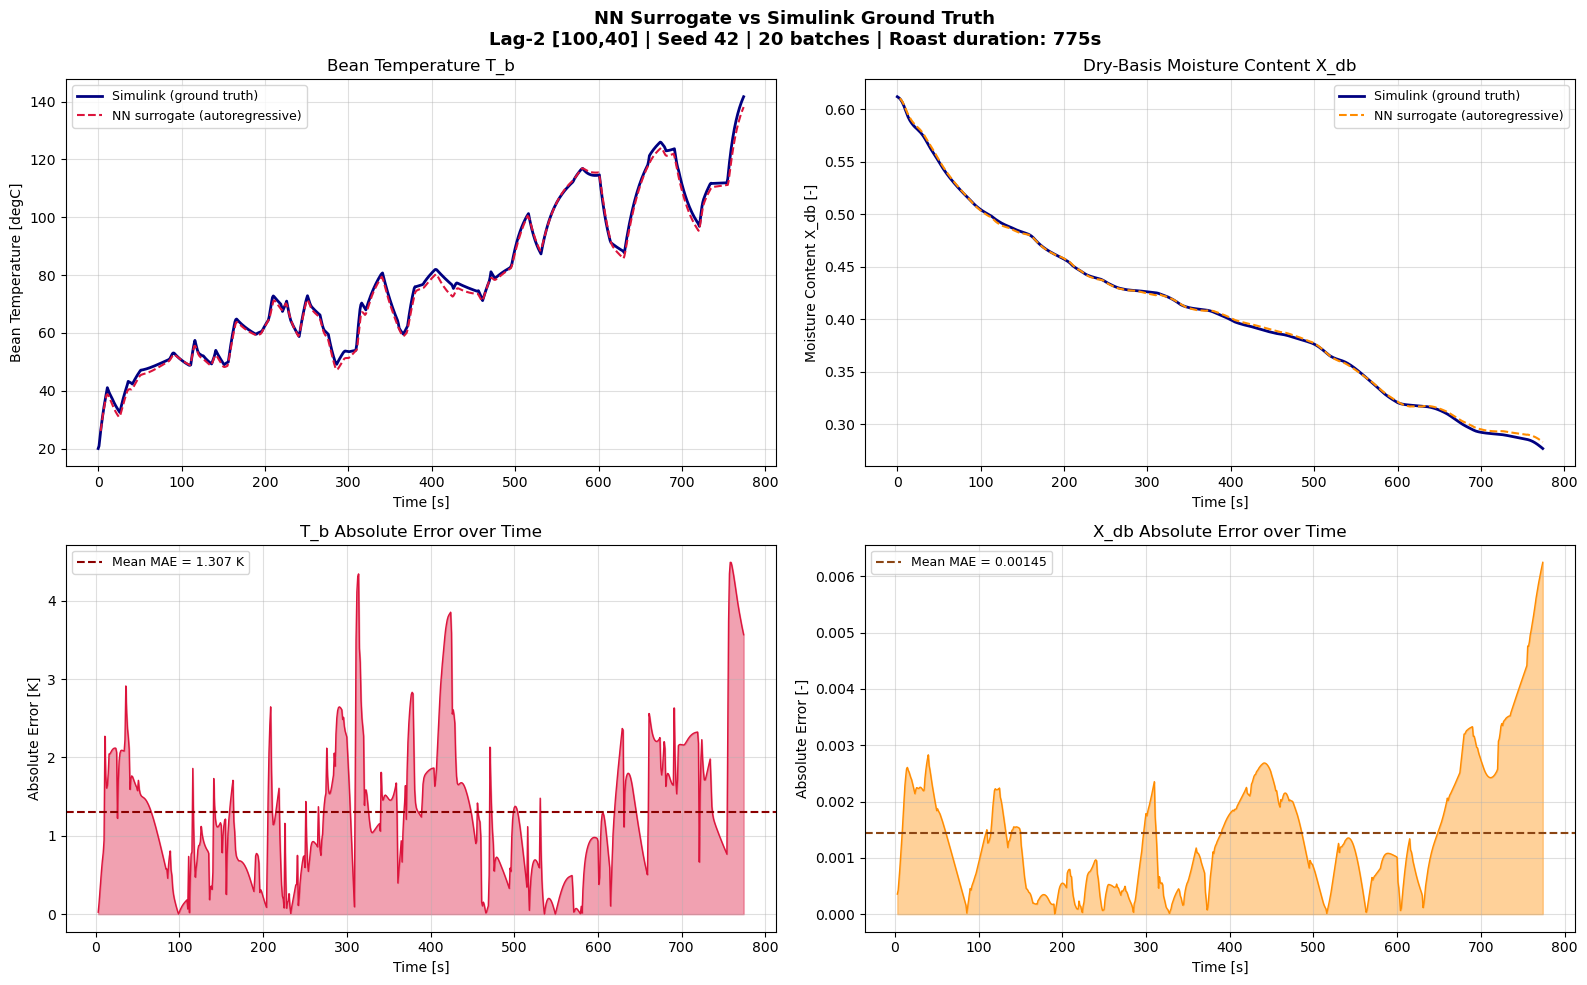

Figure saved: nn_vs_simulink_validation.png


In [89]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(
    f'NN Surrogate vs Simulink Ground Truth\n'
    f'Lag-2 [100,40] | Seed 42 | 20 batches | Roast duration: {L}s',
    fontsize=13, fontweight='bold'
)

# ── Top-left: T_b comparison ─────────────────────────────────────────────
ax = axes[0, 0]
ax.plot(time_vec, T_b_true - 273.15, color='navy', linewidth=2.0,
        label='Simulink (ground truth)')
ax.plot(time_pred, pred_Tb_plot - 273.15, color='crimson', linewidth=1.5,
        linestyle='--', label='NN surrogate (autoregressive)')
ax.set_xlabel('Time [s]')
ax.set_ylabel('Bean Temperature [degC]')
ax.set_title('Bean Temperature T_b')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.4)

# ── Top-right: X_db comparison ───────────────────────────────────────────
ax = axes[0, 1]
ax.plot(time_vec, X_db_true, color='navy', linewidth=2.0,
        label='Simulink (ground truth)')
ax.plot(time_pred, pred_X_plot, color='darkorange', linewidth=1.5,
        linestyle='--', label='NN surrogate (autoregressive)')
ax.set_xlabel('Time [s]')
ax.set_ylabel('Moisture Content X_db [-]')
ax.set_title('Dry-Basis Moisture Content X_db')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.4)

# ── Bottom-left: T_b absolute error ──────────────────────────────────────
ax = axes[1, 0]
ax.fill_between(time_pred, abs_Tb, alpha=0.4, color='crimson')
ax.plot(time_pred, abs_Tb, color='crimson', linewidth=1.0)
ax.axhline(np.mean(abs_Tb), color='darkred', linestyle='--', linewidth=1.5,
           label=f'Mean MAE = {np.mean(abs_Tb):.3f} K')
ax.set_xlabel('Time [s]')
ax.set_ylabel('Absolute Error [K]')
ax.set_title('T_b Absolute Error over Time')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.4)

# ── Bottom-right: X_db absolute error ────────────────────────────────────
ax = axes[1, 1]
ax.fill_between(time_pred, abs_X, alpha=0.4, color='darkorange')
ax.plot(time_pred, abs_X, color='darkorange', linewidth=1.0)
ax.axhline(np.mean(abs_X), color='saddlebrown', linestyle='--', linewidth=1.5,
           label=f'Mean MAE = {np.mean(abs_X):.5f}')
ax.set_xlabel('Time [s]')
ax.set_ylabel('Absolute Error [-]')
ax.set_title('X_db Absolute Error over Time')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('nn_vs_simulink_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: nn_vs_simulink_validation.png')


## 11. Relative Error Plot

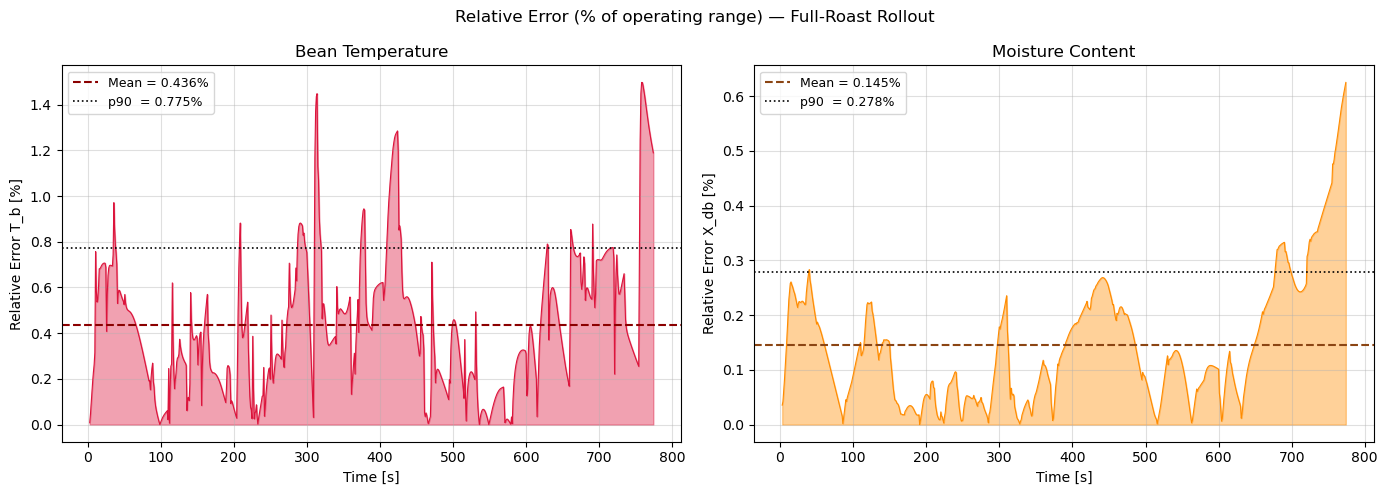

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Relative Error (% of operating range) — Full-Roast Rollout', fontsize=12)

axes[0].fill_between(time_pred, rel_Tb, alpha=0.4, color='crimson')
axes[0].plot(time_pred, rel_Tb, color='crimson', linewidth=0.8)
axes[0].axhline(np.mean(rel_Tb), color='darkred', linestyle='--', linewidth=1.5,
                label=f'Mean = {np.mean(rel_Tb):.3f}%')
axes[0].axhline(np.percentile(rel_Tb, 90), color='black', linestyle=':', linewidth=1.2,
                label=f'p90  = {np.percentile(rel_Tb, 90):.3f}%')
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('Relative Error T_b [%]')
axes[0].set_title('Bean Temperature')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.4)

axes[1].fill_between(time_pred, rel_X, alpha=0.4, color='darkorange')
axes[1].plot(time_pred, rel_X, color='darkorange', linewidth=0.8)
axes[1].axhline(np.mean(rel_X), color='saddlebrown', linestyle='--', linewidth=1.5,
                label=f'Mean = {np.mean(rel_X):.3f}%')
axes[1].axhline(np.percentile(rel_X, 90), color='black', linestyle=':', linewidth=1.2,
                label=f'p90  = {np.percentile(rel_X, 90):.3f}%')
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('Relative Error X_db [%]')
axes[1].set_title('Moisture Content')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('nn_vs_simulink_relative_error.png', dpi=150, bbox_inches='tight')
plt.show()


## 12. Overlay Multiple Validation Roasts

Run the rollout on several validation roasts and overlay the prediction curves.
This shows how consistently the surrogate tracks different roast profiles.

Roast 0 (220s): T_b MAE=3.027K, X_db MAE=0.00841
Roast 759 (604s): T_b MAE=3.932K, X_db MAE=0.01300
Roast 1518 (301s): T_b MAE=1.975K, X_db MAE=0.00411
Roast 2277 (764s): T_b MAE=1.623K, X_db MAE=0.00409
Roast 3036 (344s): T_b MAE=15.121K, X_db MAE=0.00658


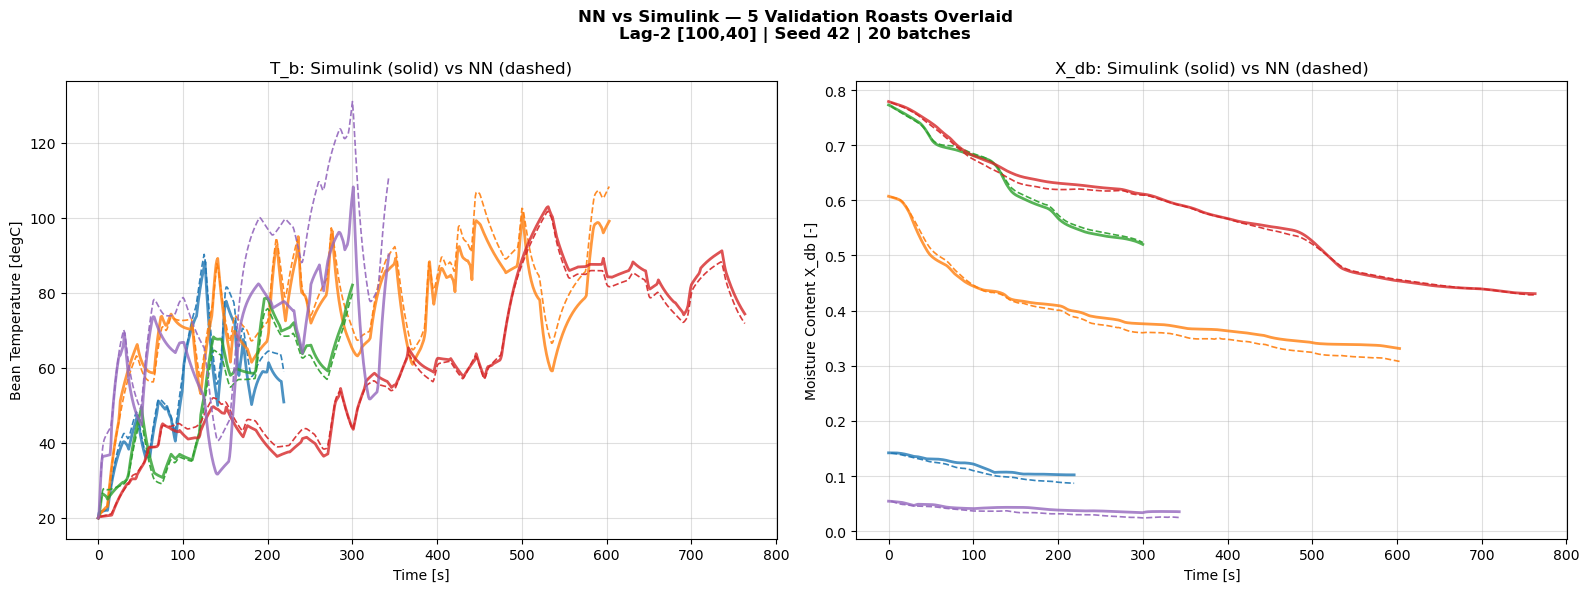

In [ ]:
N_OVERLAY         = 5     # number of roasts to overlay
RANDOM_OVERLAY    = True  # True = different roasts each run, False = fixed indices
OVERLAY_SEED      = None  # set an integer for reproducible random picks, None = truly random
OVERLAY_FIXED_IDX = [0, 750, 1500, 2250, 3000]  # used only when RANDOM_OVERLAY = False

if RANDOM_OVERLAY:
    _rng = np.random.default_rng(OVERLAY_SEED)
    selected_indices = sorted(
        _rng.choice(len(val_roasts), size=N_OVERLAY, replace=False).tolist()
    )
    print(f'Randomly selected val indices: {selected_indices}')
else:
    selected_indices = OVERLAY_FIXED_IDX[:N_OVERLAY]
    print(f'Fixed val indices: {selected_indices}')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    f'NN vs Simulink — {N_OVERLAY} Validation Roasts Overlaid\n'
    f'Lag-2 [100,40] | Seed 42 | 20 batches',
    fontsize=12, fontweight='bold'
)

colors = plt.cm.tab10.colors

for j, ridx in enumerate(selected_indices):
    _, mp, li = val_roasts[ridx]
    r = load_one_roast(mp, li)
    L_r = len(r['T_g'])

    p_Tb, p_X = full_roast_rollout(model, x_sc, y_sc, r,
                                    n_lags=LAG_DEPTH, device=DEVICE)

    tv   = r['Time']
    tpred = tv[LAG_DEPTH + 1:]
    p_Tb_plot = p_Tb[:len(tpred)]
    p_X_plot  = p_X[:len(tpred)]

    # Simulink ground truth
    axes[0].plot(tv, r['T_b'] - 273.15, color=colors[j], linewidth=2.0, alpha=0.8)
    axes[0].plot(tpred, p_Tb_plot - 273.15, color=colors[j], linewidth=1.2,
                linestyle='--', alpha=0.9,
                label=f'Roast {ridx} ({L_r}s)' if j == 0 else '_')

    axes[1].plot(tv, r['X_db'], color=colors[j], linewidth=2.0, alpha=0.8)
    axes[1].plot(tpred, p_X_plot, color=colors[j], linewidth=1.2,
                linestyle='--', alpha=0.9)

    print(f'Roast {ridx} ({L_r}s): '
          f'T_b MAE={np.mean(np.abs(p_Tb_plot - r["T_b"][LAG_DEPTH+1:LAG_DEPTH+1+len(tpred)])):.3f}K, '
          f'X_db MAE={np.mean(np.abs(p_X_plot - r["X_db"][LAG_DEPTH+1:LAG_DEPTH+1+len(tpred)])):.5f}')

for ax, ylabel, title in zip(axes,
    ['Bean Temperature [degC]', 'Moisture Content X_db [-]'],
    ['T_b: Simulink (solid) vs NN (dashed)', 'X_db: Simulink (solid) vs NN (dashed)']):
    ax.set_xlabel('Time [s]')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('nn_vs_simulink_overlay.png', dpi=150, bbox_inches='tight')
plt.show()


## 13. Summary — MPC Window Errors vs Full-Roast Rollout Errors

In [92]:
# MPC window metrics come from the saved training results
# Load from the saved CSV
import pandas as pd

csv_path = RESULTS_DIR / 'full_comparison_table.csv'
df = pd.read_csv(csv_path, index_col='model')

lag2_row = df.loc['lag-2 tuned [100,40]']

print('===== Lag-2 [100,40] — Seed 42, 20 batches =====')
print()
print('--- MPC Window Evaluation (30-second windows, stride=1) ---')
print(f'  Windows evaluated  : {int(lag2_row["n_windows"]):,}')
print(f'  T_b rel error mean : {lag2_row["rel_Tb_mean_%"]:.4f}%')
print(f'  T_b rel error p90  : {lag2_row["rel_Tb_p90_%"]:.4f}%')
print(f'  T_b MAE            : {lag2_row["mae_Tb_mean_K"]:.4f} K')
print(f'  X_db rel error mean: {lag2_row["rel_X_mean_%"]:.4f}%')
print(f'  X_db MAE           : {lag2_row["mae_X_mean"]:.6f}')
print()
print('--- Full-Roast Rollout (single roast, full duration) ---')
print(f'  Roast duration     : {L} seconds')
print(f'  Prediction steps   : {len(pred_Tb_plot)}')
print(f'  T_b rel error mean : {np.mean(rel_Tb):.4f}%')
print(f'  T_b rel error p90  : {np.percentile(rel_Tb, 90):.4f}%')
print(f'  T_b MAE            : {np.mean(abs_Tb):.4f} K')
print(f'  X_db rel error mean: {np.mean(rel_X):.4f}%')
print(f'  X_db MAE           : {np.mean(abs_X):.6f}')
print()
print('Interpretation:')
print('  Full-roast errors are higher because prediction errors accumulate')
print('  over hundreds of steps without correction from real measurements.')
print('  In the MPC deployment, errors are reset every second from real state.')
print('  The 30-second window errors are therefore the operationally relevant metric.')


===== Lag-2 [100,40] — Seed 42, 20 batches =====

--- MPC Window Evaluation (30-second windows, stride=1) ---
  Windows evaluated  : 1,964,540
  T_b rel error mean : 0.3921%
  T_b rel error p90  : 0.7516%
  T_b MAE            : 1.1762 K
  X_db rel error mean: 0.1343%
  X_db MAE           : 0.001343

--- Full-Roast Rollout (single roast, full duration) ---
  Roast duration     : 775 seconds
  Prediction steps   : 772
  T_b rel error mean : 0.4356%
  T_b rel error p90  : 0.7750%
  T_b MAE            : 1.3068 K
  X_db rel error mean: 0.1449%
  X_db MAE           : 0.001449

Interpretation:
  Full-roast errors are higher because prediction errors accumulate
  over hundreds of steps without correction from real measurements.
  In the MPC deployment, errors are reset every second from real state.
  The 30-second window errors are therefore the operationally relevant metric.
